<a href="https://colab.research.google.com/github/hd77alu/linear_regression_model/blob/main/summative/linear_regression/multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# linear Regression Model to Predict CO2 emissions in East Africa

## Dataset Information
This project uses historical country-level CO2 emissions and socioeconomic indicators from 2000 to 2020 to create a model that predicts total CO2 emissions excluding LUCF in East Africa.


**Dataset:** `africa-co2-emissions.csv`

### Dataset Characteristics:
- **Rows:** 1,134
- **Columns:** 20 total (3 non-numeric, 17 numeric)
- **Source:** [African countries CO2 emissions data](https://www.kaggle.com/datasets/victoraiyewumi/co2-emission-africa)


## libraries

In [1]:
# Importing necessary libraries

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor 

# Saving the model
import joblib
import os

## Data Processing

In [2]:
# Load data
df = pd.read_csv('data/africa-co2-emissions.csv')

# See data info
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1134 entries, 0 to 1133
Data columns (total 20 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 1134 non-null   str    
 1   Sub-Region                              1134 non-null   str    
 2   Code                                    1134 non-null   str    
 3   Year                                    1134 non-null   int64  
 4   Population                              1134 non-null   int64  
 5   GDP PER CAPITA (USD)                    1107 non-null   float64
 6   GDP PER CAPITA PPP (USD)                1086 non-null   float64
 7   Area (Km2)                              1134 non-null   int64  
 8   Transportation (Mt)                     1122 non-null   float64
 9   Total CO2 Emission including LUCF (Mt)  1134 non-null   float64
 10  Total CO2 Emission excluding LUCF (Mt)  1134 non-null   float64
 11  Ot

,Country,Sub-Region,Code,Year,Population,GDP PER CAPITA (USD),GDP PER CAPITA PPP (USD),Area (Km2),Transportation (Mt),Total CO2 Emission including LUCF (Mt),Total CO2 Emission excluding LUCF (Mt),Other Fuel Combustion (Mt),Manufacturing/Construction (Mt),Land-Use Change and Forestry (Mt),Industrial Processes (Mt),Fugitive Emissions (Mt),Energy (Mt),Electricity/Heat (Mt),Bunker Fuels (Mt),Building (Mt)
0,Algeria,Northern Africa,DZA,2000,30774621,1780.38,8510.36,2381741,16.85,80.62,80.05,0.0,6.16,0.57,3.79,14.75,76.26,29.17,1.96,9.33
1,Algeria,Northern Africa,DZA,2001,31200985,1754.58,8840.67,2381741,17.04,76.24,78.65,0.0,6.25,-2.41,3.77,11.86,74.88,30.20,1.98,9.53
2,Algeria,Northern Africa,DZA,2002,31624696,1794.81,9354.22,2381741,19.36,80.00,82.40,0.0,6.62,-2.41,4.06,10.20,78.35,32.28,2.17,9.89
3,Algeria,Northern Africa,DZA,2003,32055883,2117.05,10088.09,2381741,21.76,85.78,88.19,0.0,7.01,-2.41,4.03,12.17,84.16,32.53,1.89,10.68
4,Algeria,Northern Africa,DZA,2004,32510186,2624.80,10653.34,2381741,22.03,87.09,89.49,0.0,8.09,-2.41,4.90,11.22,84.60,31.75,2.19,11.52


In [3]:
# Replace string placeholders for missing values
df = df.replace(['N/A', 'na', 'NA', ''], np.nan)

# Keep only East Africa rows
df_east = df[df['Sub-Region'] == 'Eastern Africa'].copy()

# Define target column
target_col = 'Total CO2 Emission excluding LUCF (Mt)'

# Numeric columns to use for analysis/modeling
numeric_cols = [
    'Year',
    'Population',
    'GDP PER CAPITA (USD)',
    'GDP PER CAPITA PPP (USD)',
    'Area (Km2)',
    'Transportation (Mt)',
    'Other Fuel Combustion (Mt)',
    'Manufacturing/Construction (Mt)',
    'Land-Use Change and Forestry (Mt)',
    'Industrial Processes (Mt)',
    'Fugitive Emissions (Mt)',
    'Energy (Mt)',
    'Electricity/Heat (Mt)',
    'Bunker Fuels (Mt)',
    'Building (Mt)',
    target_col,
]

# Ensure numeric dtype
for col in numeric_cols:
    df_east[col] = pd.to_numeric(df_east[col], errors='coerce')

# Show basic checks
print('East Africa rows:', len(df_east))
print('East Africa countries:', df_east['Country'].nunique())
print('\nMissing values by selected column:')
print(df_east[numeric_cols].isna().sum().sort_values(ascending=False))

# Drop very sparse column to keep analysis stable
if 'Fugitive Emissions (Mt)' in df_east.columns:
    df_east = df_east.drop(columns=['Fugitive Emissions (Mt)'])
    numeric_cols.remove('Fugitive Emissions (Mt)')

# Country-wise median imputation for predictors
predictor_cols = [c for c in numeric_cols if c != target_col]
country_medians = df_east.groupby('Country')[predictor_cols].transform('median')
df_east[predictor_cols] = df_east[predictor_cols].fillna(country_medians)

# Global median fallback for any remaining missing predictor values
df_east[predictor_cols] = df_east[predictor_cols].fillna(
    df_east[predictor_cols].median(numeric_only=True)
)

# Keep only rows with target available for the model
df_east = df_east.dropna(subset=[target_col])

# Keep a compact feature subset for visuals
feature_cols = [
    'Year',
    'GDP PER CAPITA (USD)',
    'Population',
    'Transportation (Mt)',
    'Energy (Mt)',
    'Electricity/Heat (Mt)',
    'Building (Mt)',
    target_col,
]

print('\nPreview of cleaned East Africa data:')
display(df_east[['Country', 'Sub-Region', 'Code'] + feature_cols].head())

df_east[feature_cols].describe()

East Africa rows: 378
East Africa countries: 18

Missing values by selected column:
Fugitive Emissions (Mt)                   370
GDP PER CAPITA PPP (USD)                   47
Industrial Processes (Mt)                  35
GDP PER CAPITA (USD)                       26
Manufacturing/Construction (Mt)            12
Bunker Fuels (Mt)                          12
Other Fuel Combustion (Mt)                 12
Transportation (Mt)                        12
Building (Mt)                              12
Electricity/Heat (Mt)                      12
Population                                  0
Year                                        0
Area (Km2)                                  0
Land-Use Change and Forestry (Mt)           0
Energy (Mt)                                 0
Total CO2 Emission excluding LUCF (Mt)      0
dtype: int64

Preview of cleaned East Africa data:


,Country,Sub-Region,Code,Year,GDP PER CAPITA (USD),Population,Transportation (Mt),Energy (Mt),Electricity/Heat (Mt),Building (Mt),Total CO2 Emission excluding LUCF (Mt)
105,Burundi,Eastern Africa,BDI,2000,138.00,6307659,0.19,0.26,0.0,0.02,0.26
106,Burundi,Eastern Africa,BDI,2001,135.61,6465729,0.14,0.21,0.0,0.03,0.21
107,Burundi,Eastern Africa,BDI,2002,124.14,6648938,0.17,0.22,0.0,0.02,0.22
108,Burundi,Eastern Africa,BDI,2003,114.37,6860846,0.13,0.17,0.0,0.02,0.17
109,Burundi,Eastern Africa,BDI,2004,128.54,7120496,0.12,0.16,0.0,0.01,0.16


,Year,GDP PER CAPITA (USD),Population,Transportation (Mt),Energy (Mt),Electricity/Heat (Mt),Building (Mt),Total CO2 Emission excluding LUCF (Mt)
count,378.000000,378.000000,3.780000e+02,378.000000,378.000000,378.000000,378.000000,378.000000
mean,2010.000000,1801.481534,1.919967e+07,1.393042,3.184127,0.827884,0.239603,3.538545
std,6.063326,3194.332915,2.236011e+07,1.758340,3.787749,1.337460,0.370448,4.393707
min,2000.000000,110.460000,8.113100e+04,0.050000,0.110000,0.000000,0.010000,0.100000
25%,2005.000000,401.715000,3.162688e+06,0.172500,0.570000,0.090000,0.040000,0.582500
50%,2010.000000,680.810000,1.212442e+07,0.890000,1.490000,0.250000,0.100000,1.570000
75%,2015.000000,1390.320000,2.515153e+07,1.972500,4.255000,1.007500,0.200000,4.792500
max,2020.000000,16851.120000,1.171909e+08,10.730000,16.990000,6.920000,2.200000,20.100000


## Data visualizations

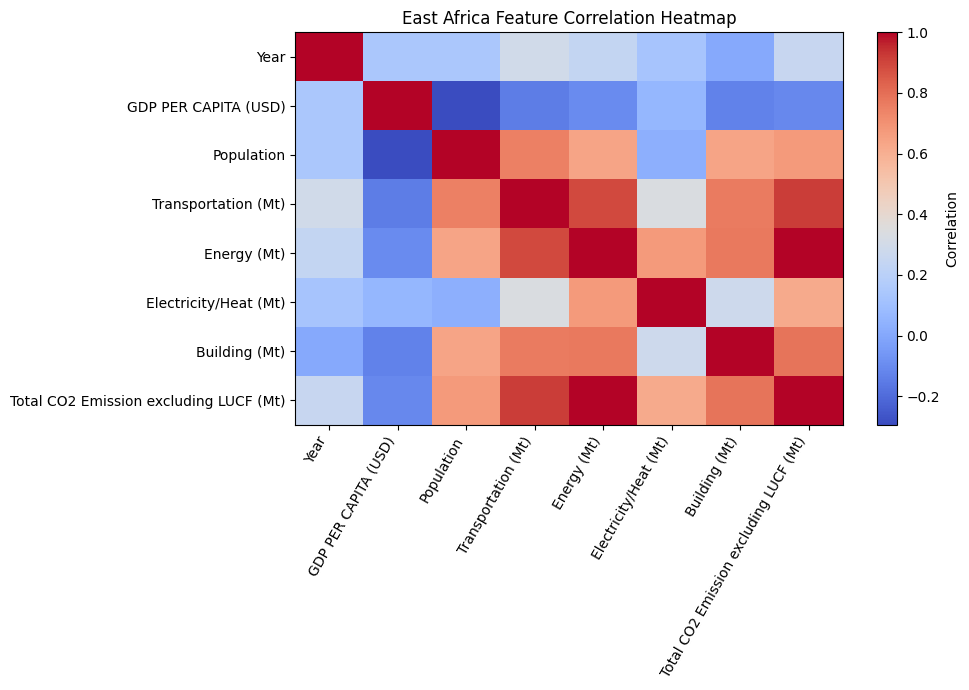

In [4]:
# Correlation heatmap
corr_matrix = df_east[feature_cols].corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest', aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=60, ha='right')
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title('East Africa Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### Insights from the heatmap

- `Total CO2 Emission excluding LUCF (Mt)` has a strong positive correlation with `Energy (Mt)`.
- The target also shows strong positive relationships with `Transportation (Mt)` and `Building (Mt)`.
- `Population` has a moderate-to-strong positive association with the target, suggesting demographic scale matters.
- `Year` appears weakly positive with the target, indicating a mild time trend in East Africa.
- `GDP PER CAPITA (USD)` shows a weak relationship with the target in this subset.
- Several predictors are strongly correlated with each other (for example, `Energy (Mt)`, `Transportation (Mt)`, and `Building (Mt)`), which signals potential multicollinearity.

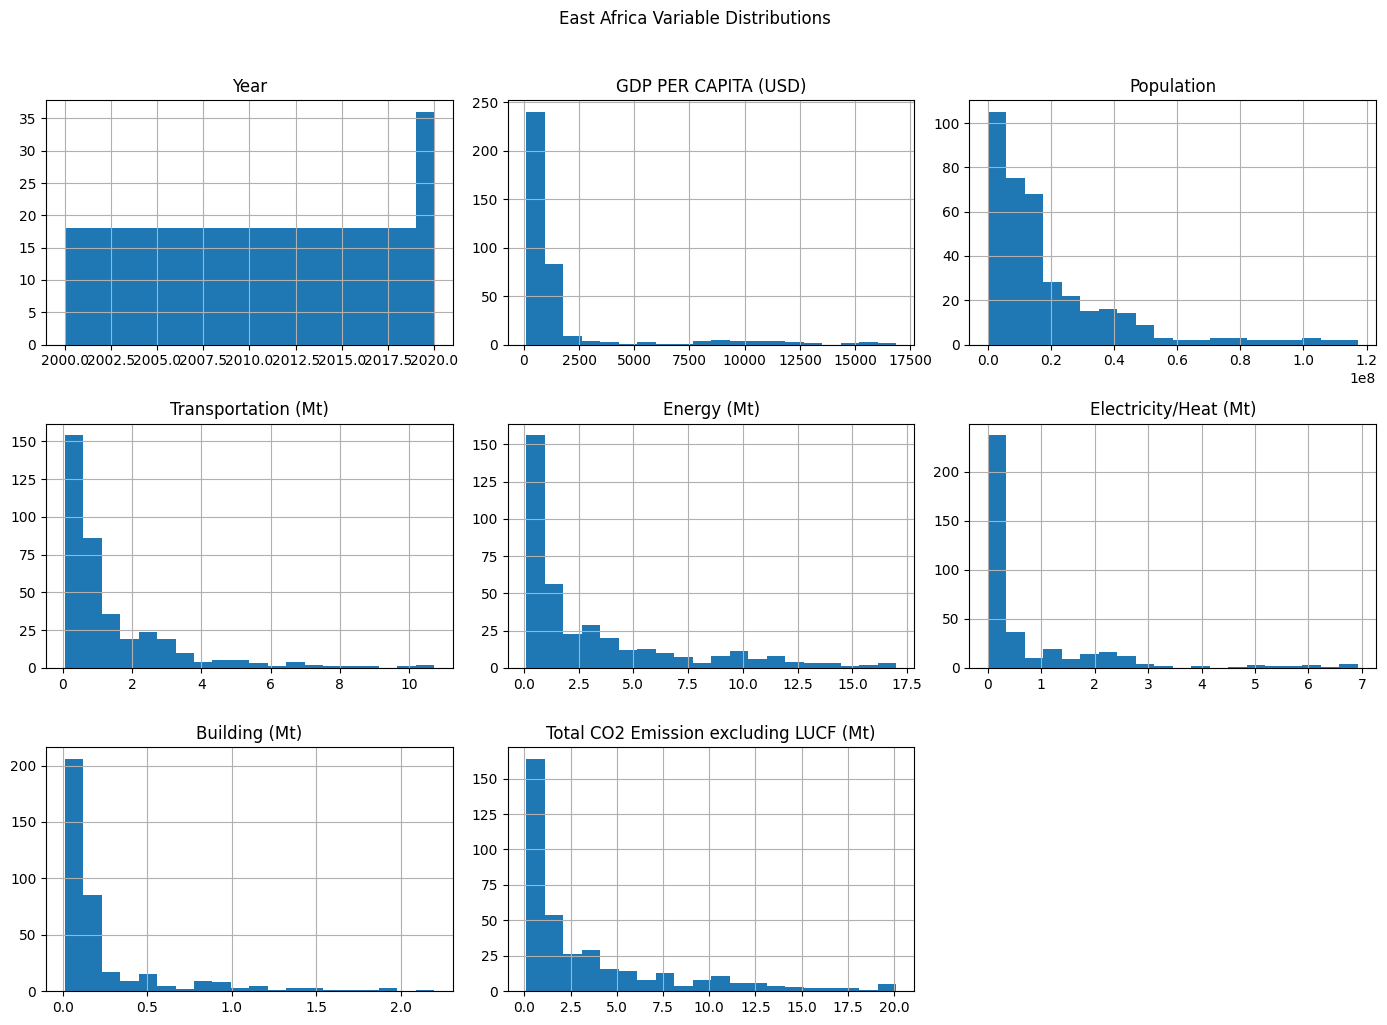

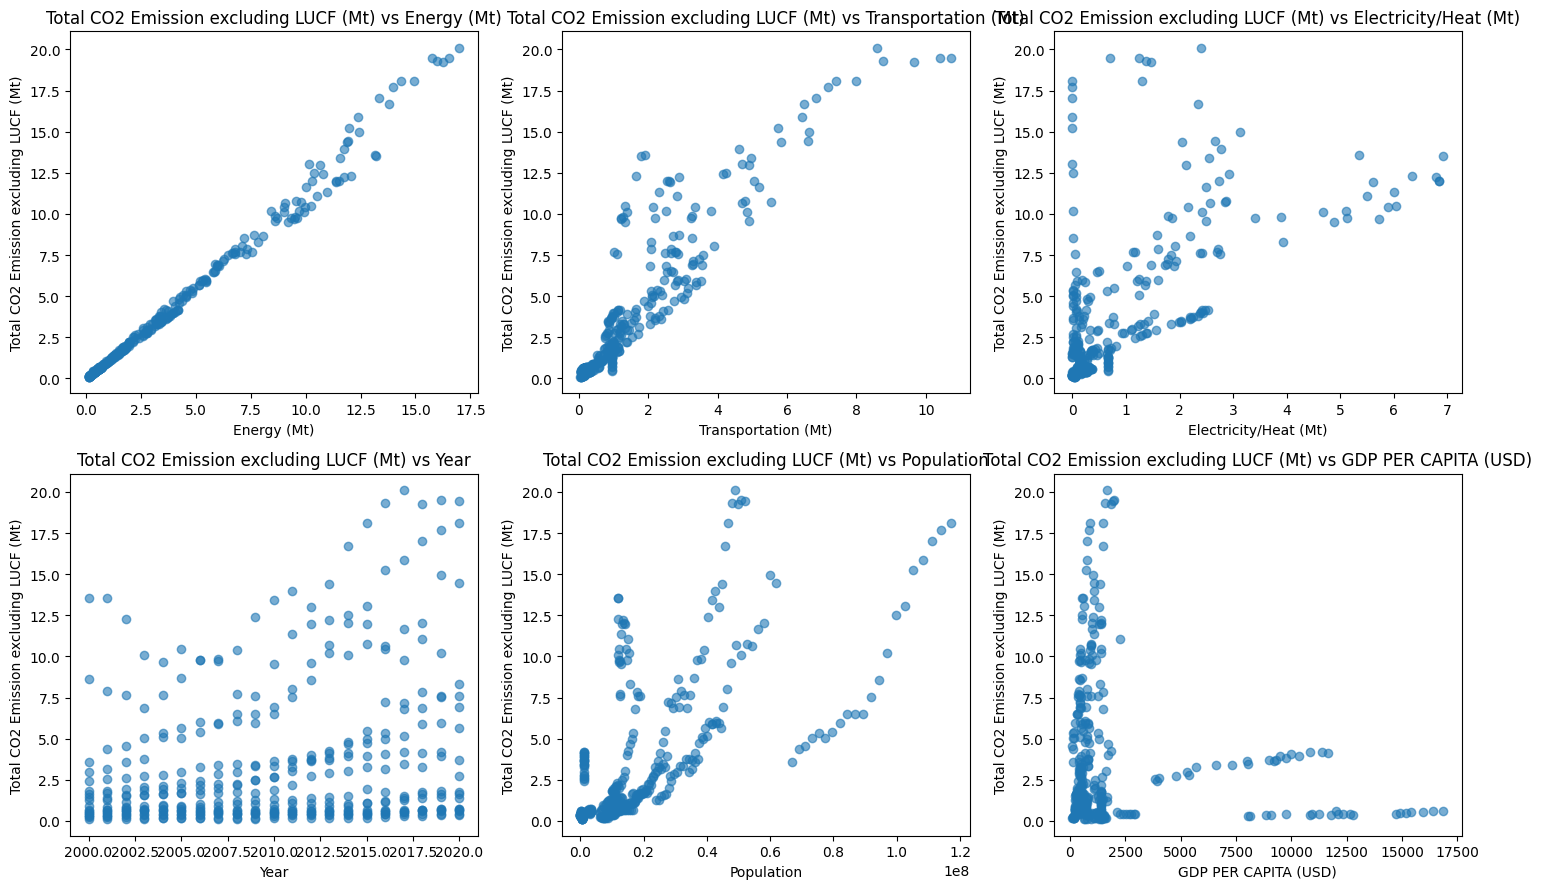

In [5]:
# Histograms for variable distributions
df_east[feature_cols].hist(figsize=(14, 10), bins=20)
plt.suptitle('East Africa Variable Distributions', y=1.02)
plt.tight_layout()
plt.show()

# Scatterplots (relationship view)
plot_pairs = [
    ('Energy (Mt)', target_col),
    ('Transportation (Mt)', target_col),
    ('Electricity/Heat (Mt)', target_col),
    ('Year', target_col),
    ('Population', target_col),
    ('GDP PER CAPITA (USD)', target_col),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for i, (x_col, y_col) in enumerate(plot_pairs):
    axes[i].scatter(df_east[x_col], df_east[y_col], alpha=0.6)
    axes[i].set_xlabel(x_col)
    axes[i].set_ylabel(y_col)
    axes[i].set_title(f'{y_col} vs {x_col}')

plt.tight_layout()
plt.show()

## Feature engineering


In [6]:
# Feature Engineering: decide what to keep, drop, and why
fe_df = df_east.copy()

# Explicit drops (leakage/redundancy/very sparse)
explicit_drop_reasons = {
    'Code': 'Country code duplicates country identity and adds little predictive value.',
    'Total CO2 Emission including LUCF (Mt)': 'Strong overlap with target definition; can create leakage-like behavior.',
    'Fugitive Emissions (Mt)': 'Extremely sparse in East Africa subset.',
    'GDP PER CAPITA PPP (USD)': 'Highly related to GDP per capita; keep one GDP measure for simplicity.',
}

for col in list(explicit_drop_reasons.keys()):
    if col in fe_df.columns:
        fe_df = fe_df.drop(columns=[col])

# Create engineered features
fe_df['Population Density (people per km2)'] = fe_df['Population'] / fe_df['Area (Km2)']

# Candidate numeric features for interpretation
numeric_candidates = [
    'Year',
    'GDP PER CAPITA (USD)',
    'Population',
    'Area (Km2)',
    'Population Density (people per km2)',
    'Transportation (Mt)',
    'Other Fuel Combustion (Mt)',
    'Manufacturing/Construction (Mt)',
    'Land-Use Change and Forestry (Mt)',
    'Industrial Processes (Mt)',
    'Energy (Mt)',
    'Electricity/Heat (Mt)',
    'Bunker Fuels (Mt)',
    'Building (Mt)',
]

numeric_candidates = [c for c in numeric_candidates if c in fe_df.columns]

# Feature weight proxy: correlation with target (absolute strength)
feature_strength = (
    fe_df[numeric_candidates + [target_col]]
    .corr()[target_col]
    .drop(target_col)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print('Feature strength relative to target (correlation):')
print(feature_strength)


Feature strength relative to target (correlation):
Energy (Mt)                            0.995850
Transportation (Mt)                    0.917815
Manufacturing/Construction (Mt)        0.915359
Industrial Processes (Mt)              0.872299
Building (Mt)                          0.782795
Population                             0.673302
Electricity/Heat (Mt)                  0.616510
Other Fuel Combustion (Mt)             0.604961
Bunker Fuels (Mt)                      0.557111
Area (Km2)                             0.506037
Land-Use Change and Forestry (Mt)      0.386245
Year                                   0.253738
Population Density (people per km2)   -0.207137
GDP PER CAPITA (USD)                  -0.108299
Name: Total CO2 Emission excluding LUCF (Mt), dtype: float64


In [7]:
# Final feature set for the Model

# Add concise drop reasons used in this final selection
explicit_drop_reasons.update({
    'Energy (Mt)': 'High leakage risk, Almost perfect correlation with target',
    'Industrial Processes (Mt)': 'High overlap with transport',
    'Other Fuel Combustion (Mt)': 'Overlaps with energy effects',
    'GDP PER CAPITA (USD)': 'Weak target relationship',
    'Population Density (people per km2)': 'Derived and weak signal',
    'Area (Km2)': 'Captured via population scale',
})

print('Explicit drop reasons:')
print(explicit_drop_reasons)

final_features = [
    'Country',
    'Year',
    'Population',
    'Transportation (Mt)',
    'Manufacturing/Construction (Mt)',
    'Electricity/Heat (Mt)',
    'Building (Mt)',
]

final_features = [c for c in final_features if c in fe_df.columns]

# Build model-ready frame for next sections
model_df = fe_df[final_features + [target_col]].copy()

# Summarize engineering decisions with short reasons
decision_rows = []
for col, reason in explicit_drop_reasons.items():
    if col in fe_df.columns:
        decision_rows.append({'Column': col, 'Decision': 'Drop', 'Reason': reason})

for col in final_features:
    decision_rows.append({
        'Column': col,
        'Decision': 'Keep',
        'Reason': 'High correlation, lower leakage risk'
    })

decision_table = pd.DataFrame(decision_rows)

print('\nFinal modeling dataset shape:', model_df.shape)
print('Final features:', final_features)

display(decision_table)

Explicit drop reasons:
{'Code': 'Country code duplicates country identity and adds little predictive value.', 'Total CO2 Emission including LUCF (Mt)': 'Strong overlap with target definition; can create leakage-like behavior.', 'Fugitive Emissions (Mt)': 'Extremely sparse in East Africa subset.', 'GDP PER CAPITA PPP (USD)': 'Highly related to GDP per capita; keep one GDP measure for simplicity.', 'Energy (Mt)': 'High leakage risk, Almost perfect correlation with target', 'Industrial Processes (Mt)': 'High overlap with transport', 'Other Fuel Combustion (Mt)': 'Overlaps with energy effects', 'GDP PER CAPITA (USD)': 'Weak target relationship', 'Population Density (people per km2)': 'Derived and weak signal', 'Area (Km2)': 'Captured via population scale'}

Final modeling dataset shape: (378, 8)
Final features: ['Country', 'Year', 'Population', 'Transportation (Mt)', 'Manufacturing/Construction (Mt)', 'Electricity/Heat (Mt)', 'Building (Mt)']


,Column,Decision,Reason
0,Energy (Mt),Drop,"High leakage risk, Almost perfect correlation ..."
1,Industrial Processes (Mt),Drop,High overlap with transport
2,Other Fuel Combustion (Mt),Drop,Overlaps with energy effects
3,GDP PER CAPITA (USD),Drop,Weak target relationship
4,Population Density (people per km2),Drop,Derived and weak signal
5,Area (Km2),Drop,Captured via population scale
6,Country,Keep,"High correlation, lower leakage risk"
7,Year,Keep,"High correlation, lower leakage risk"
8,Population,Keep,"High correlation, lower leakage risk"
9,Transportation (Mt),Keep,"High correlation, lower leakage risk"


## Data standardization

In [8]:
# Data standardization
# Prepare features (X) and target (y)
X = model_df.drop(columns=[target_col]).copy()
y = model_df[target_col].copy()

# Identify column types
categorical_features = [c for c in ['Country'] if c in X.columns]
numeric_features = [c for c in X.columns if c not in categorical_features]

# Standardize only numeric features
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_features] = scaler.fit_transform(X[numeric_features])

print('Categorical features:', categorical_features)
print('Numeric features standardized:', numeric_features)
print('X shape:', X.shape, '| y shape:', y.shape)

# Quick validation of standardization (mean ~0, std ~1)
summary = pd.DataFrame({
    'mean_after_scaling': X_scaled[numeric_features].mean().round(3),
    'std_after_scaling': X_scaled[numeric_features].std().round(3)
})
display(summary)

# Preview standardized feature matrix
X_scaled.head()

Categorical features: ['Country']
Numeric features standardized: ['Year', 'Population', 'Transportation (Mt)', 'Manufacturing/Construction (Mt)', 'Electricity/Heat (Mt)', 'Building (Mt)']
X shape: (378, 7) | y shape: (378,)


,mean_after_scaling,std_after_scaling
Year,0.0,1.001
Population,0.0,1.001
Transportation (Mt),0.0,1.001
Manufacturing/Construction (Mt),0.0,1.001
Electricity/Heat (Mt),0.0,1.001
Building (Mt),0.0,1.001


,Country,Year,Population,Transportation (Mt),Manufacturing/Construction (Mt),Electricity/Heat (Mt),Building (Mt)
105,Burundi,-1.651446,-0.577327,-0.685099,-0.603410,-0.619817,-0.593590
106,Burundi,-1.486301,-0.570249,-0.713572,-0.614356,-0.619817,-0.566559
107,Burundi,-1.321157,-0.562044,-0.696488,-0.636247,-0.619817,-0.593590
108,Burundi,-1.156012,-0.552555,-0.719267,-0.636247,-0.619817,-0.593590
109,Burundi,-0.990867,-0.540927,-0.724962,-0.636247,-0.619817,-0.620620


## Train-test split

In [9]:
# Train-test split (80-20)
# Encode categorical columns before splitting
X_model = pd.get_dummies(X_scaled, columns=categorical_features, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, random_state=42
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train.head()

X_train shape: (302, 23)
X_test shape: (76, 23)
y_train shape: (302,)
y_test shape: (76,)


,Year,Population,Transportation (Mt),Manufacturing/Construction (Mt),Electricity/Heat (Mt),Building (Mt),Country_Comoros,Country_Djibouti,Country_Eritrea,Country_Ethiopia,...,Country_Mauritius,Country_Mozambique,Country_Rwanda,Country_Seychelles,Country_Somalia,Country_South Sudan,Country_Tanzania,Country_Uganda,Country_Zambia,Country_Zimbabwe
599,0.165145,0.140995,-0.223827,-0.307873,-0.133177,-0.242198,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
395,1.156012,3.985501,2.868406,4.103291,-0.619817,0.649795,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1028,1.651446,1.903442,2.970911,1.629537,1.371664,0.649795,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1014,-0.660578,0.956645,0.835391,-0.154631,0.570579,0.757915,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
832,0.495434,-0.362657,-0.514257,-0.537735,-0.492542,-0.404379,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False


## Model training (Linear Regression, Decision Tree, Random Forest)

In [10]:
# Model training
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
}

trained_models = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    predictions[name] = model.predict(X_test)

print('Models trained:', list(trained_models.keys()))

Models trained: ['Linear Regression', 'Decision Tree', 'Random Forest']


In [11]:
# Quick test: compare a few predictions vs actual values for all models

# Show original test set samples for context
test_origin = model_df.loc[y_test.index, ['Country', 'Year', target_col]].copy()
print('Original test set samples (Country, Year, Actual CO2):')
display(test_origin.head(10))

# Show a quick comparison of actual vs predicted for the first 10 rows of the test set
n_rows = 10

for model_name, y_pred in predictions.items():
    comparison_df = pd.DataFrame({
        'Actual': y_test.reset_index(drop=True),
        'Predicted': y_pred
    })
    comparison_df['Absolute Error'] = (comparison_df['Actual'] - comparison_df['Predicted']).abs()

    print(f'\nQuick comparison using {model_name}:')
    display(comparison_df.head(n_rows))
    print(
        f"Mean Absolute Error on shown {n_rows} rows:",
        comparison_df.head(n_rows)['Absolute Error'].mean().round(2)
    )

Original test set samples (Country, Year, Actual CO2):


,Country,Year,Total CO2 Emission excluding LUCF (Mt)
980,South Sudan,2014,1.52
1085,Uganda,2014,4.11
1079,Uganda,2008,2.97
607,Madagascar,2019,3.93
286,Djibouti,2013,0.56
387,Ethiopia,2009,6.53
1096,Zambia,2004,2.11
355,Eritrea,2019,0.70
1121,Zimbabwe,2008,7.71
610,Malawi,2001,0.85



Quick comparison using Linear Regression:


,Actual,Predicted,Absolute Error
0,1.52,1.060677,0.459323
1,4.11,4.251074,0.141074
2,2.97,2.891536,0.078464
3,3.93,3.969711,0.039711
4,0.56,0.538207,0.021793
5,6.53,6.612661,0.082661
6,2.11,2.212325,0.102325
7,0.70,0.654788,0.045212
8,7.71,7.199410,0.510590
9,0.85,0.853981,0.003981


Mean Absolute Error on shown 10 rows: 0.15

Quick comparison using Decision Tree:


,Actual,Predicted,Absolute Error
0,1.52,1.42,0.10
1,4.11,3.69,0.42
2,2.97,2.87,0.10
3,3.93,3.48,0.45
4,0.56,0.52,0.04
5,6.53,5.87,0.66
6,2.11,2.08,0.03
7,0.70,0.68,0.02
8,7.71,9.75,2.04
9,0.85,0.89,0.04


Mean Absolute Error on shown 10 rows: 0.39

Quick comparison using Random Forest:


,Actual,Predicted,Absolute Error
0,1.52,1.570933,0.050933
1,4.11,4.456433,0.346433
2,2.97,2.981933,0.011933
3,3.93,3.441767,0.488233
4,0.56,0.501200,0.058800
5,6.53,6.216300,0.313700
6,2.11,2.150100,0.040100
7,0.70,0.678100,0.021900
8,7.71,8.879167,1.169167
9,0.85,0.853667,0.003667


Mean Absolute Error on shown 10 rows: 0.25


## Best model selection

In [12]:
# Model evaluation (MSE)
results = []

for name, y_pred in predictions.items():
    mse = mean_squared_error(y_test, y_pred)
    results.append({'Model': name, 'MSE': mse})

results_df = pd.DataFrame(results).sort_values('MSE').reset_index(drop=True)

# Best model selection (based on MSE metric)
best_model_name = results_df.loc[0, 'Model']
best_model = trained_models[best_model_name]

display(results_df)
print('Best model (lowest MSE):', best_model_name)

,Model,MSE
0,Linear Regression,0.051415
1,Random Forest,0.294809
2,Decision Tree,0.574754


Best model (lowest MSE): Linear Regression


## Save best model

In [13]:
# Save best model with joblib inside the final_model folder

model_dir = 'final_model'
os.makedirs(model_dir, exist_ok=True)

safe_model_name = best_model_name.lower().replace(' ', '_')
model_path = os.path.join(model_dir, f'best_{safe_model_name}_model.joblib')

joblib.dump(best_model, model_path)
print(f'{best_model_name} model saved to: {model_path}')

Linear Regression model saved to: final_model\best_linear_regression_model.joblib


## Loss curves (train vs test)

,Model,Train MSE,Test MSE
0,Linear Regression,3.048127e-02,0.051415
1,Decision Tree,3.061081e-35,0.574754
2,Random Forest,3.448649e-02,0.294809


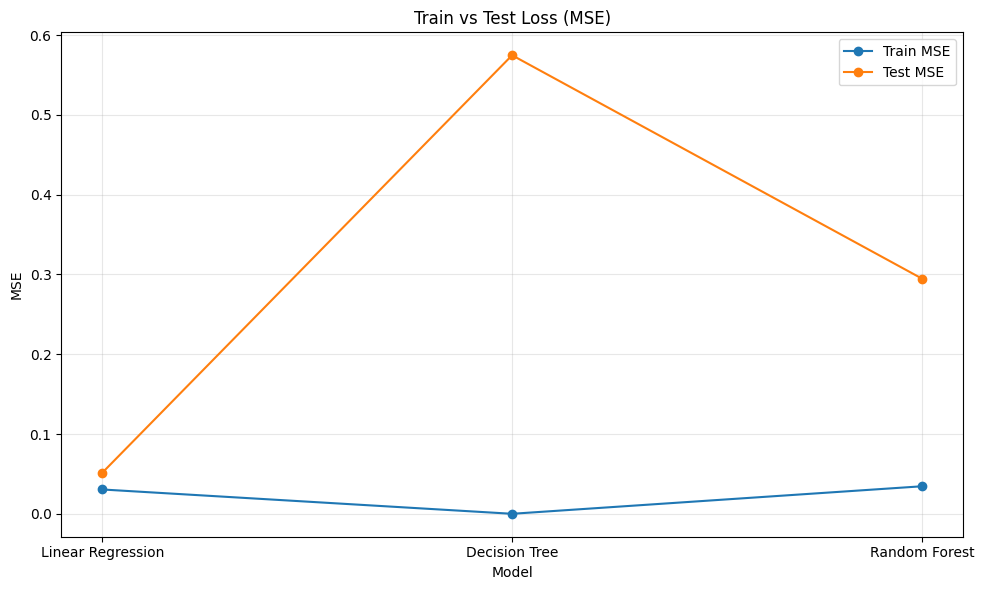

In [14]:
# Loss comparison plot (train vs test MSE)
train_test_losses = []

for name, model in trained_models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_test_losses.append({
        'Model': name,
        'Train MSE': train_mse,
        'Test MSE': test_mse
    })

loss_df = pd.DataFrame(train_test_losses)
display(loss_df)

plt.figure(figsize=(10, 6))
plt.plot(loss_df['Model'], loss_df['Train MSE'], marker='o', label='Train MSE')
plt.plot(loss_df['Model'], loss_df['Test MSE'], marker='o', label='Test MSE')
plt.title('Train vs Test Loss (MSE)')
plt.xlabel('Model')
plt.ylabel('MSE')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Before vs after scatterplot (fitted line)

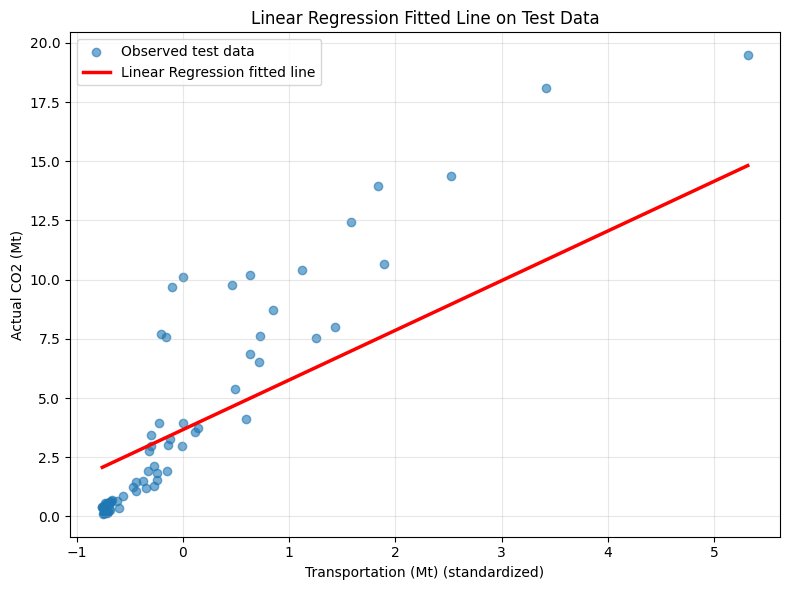

In [15]:
# Scatter plot with fitted linear regression line (trained model)
linear_regression_model = trained_models['Linear Regression']

# Choose one feature to visualize the fitted line against
plot_feature = 'Transportation (Mt)'
if plot_feature not in X_test.columns:
    raise KeyError(f"{plot_feature} is not present in X_test columns")

# Scatter: observed target vs chosen feature (test set)
x_obs = X_test[plot_feature]
y_obs = y_test
plt.figure(figsize=(8, 6))
plt.scatter(x_obs, y_obs, alpha=0.6, label='Observed test data')

# Build a straight fitted line from the trained Linear Regression model
x_line = np.linspace(x_obs.min(), x_obs.max(), 120)
baseline = X_test.mean(numeric_only=True)
line_df = pd.DataFrame([baseline] * len(x_line), columns=X_test.columns)
line_df[plot_feature] = x_line
y_line = linear_regression_model.predict(line_df)

plt.plot(x_line, y_line, color='red', linewidth=2.5, label='Linear Regression fitted line')
plt.title('Linear Regression Fitted Line on Test Data')
plt.xlabel(f'{plot_feature} (standardized)')
plt.ylabel('Actual CO2 (Mt)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Final Notes

- **Data processing:** The dataset was cleaned by replacing placeholder missing values, filtering to Eastern Africa only, converting selected fields to numeric, dropping a very sparse column (`Fugitive Emissions (Mt)`), applying **country-wise median imputation** for predictors with a global median fallback, and dropping rows where the target was missing. This made the training data more stable and reduced noise from inconsistent missingness patterns.
- **Feature engineering:** Features with strong overlap/leakage risk or weak contribution were removed, and a compact final feature set was kept to balance interpretability and predictive signal. This helped the models learn from meaningful predictors while limiting redundant information.
- **Primary evaluation metric:** Mean Squared Error (MSE) was used for model ranking because it directly measures regression error magnitude and penalizes large misses more strongly.
- **Train vs test MSE gap across models:** The Decision Tree and Random Forest achieved very low training error but showed a larger increase on test MSE, indicating higher variance and some overfitting on this dataset.
- **Why Linear Regression has the smallest gap:** Linear Regression handles data with Continuous numeric variables better than the other two models, which are more suited to categorical data. In this project, relationships were close to linear after preprocessing and feature selection, so the linear model generalized more consistently from train to test and produced the smallest train-test MSE gap.
- **Best-model selection:** The model with the **lowest test MSE** was selected as the final model, and this aligned with the strongest generalization behavior.
- **Prediction behavior check:** Actual-vs-predicted sample comparisons and the fitted-line visualization were used as sanity checks to confirm that predicted values followed the observed trend.
- **Deployment:** The saved artifact can be loaded by the API inference script to produce single or batch predictions with the same preprocessing logic used during training.